<a href="https://colab.research.google.com/github/greeshmapj/AI-course-notes/blob/main/Sec23_bootcamp_unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔵 1️⃣ K-Means Clustering

## **Type**
Centroid-based clustering  

## **How It Works**
- Choose **K** clusters  
- Initialize centroids  
- Assign points to nearest centroid  
- Update centroids iteratively  
- Repeat until convergence  

## **Strengths**
- Fast  
- Scales well to large datasets  
- Simple to explain  
- Works well when clusters are spherical  

## **Weaknesses**
- Must choose **K** beforehand  
- Sensitive to outliers  
- Fails for irregular-shaped clusters  

## **For Recommendation Systems**
- User segmentation  
- Product grouping  
- Large datasets  
- Most practical for large-scale recommendation systems  

---





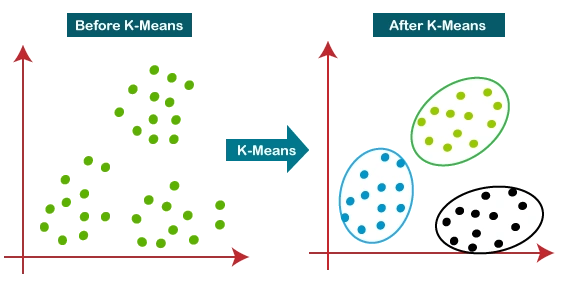

In [ ]:
import pandas as pd
df=pd.read_csv("/content/_clustering data - Sheet1.csv")
df

,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate,Country
0,1548.814,55.68434,68.20993,15.046950,61.35474,38.558030,Country 1
1,1715.189,50.18790,60.97101,21.778170,62.98282,30.117140,Country 2
2,1602.763,56.17635,68.37945,17.700080,65.69965,33.599780,Country 3
3,1544.883,56.12096,60.96098,22.351940,65.90873,37.299910,Country 4
4,1423.655,56.16934,69.76459,24.621890,65.74325,31.716300,Country 5
...,...,...,...,...,...,...,...
95,3490.305,78.81720,89.06733,9.610557,86.33461,14.979620,Country 96
96,3989.410,72.72437,90.52078,5.447473,94.80580,8.621891,Country 97
97,3065.304,73.79057,87.71653,7.029712,93.71786,9.706489,Country 98
98,3783.234,73.74296,89.55444,5.121566,90.02721,8.782452,Country 99


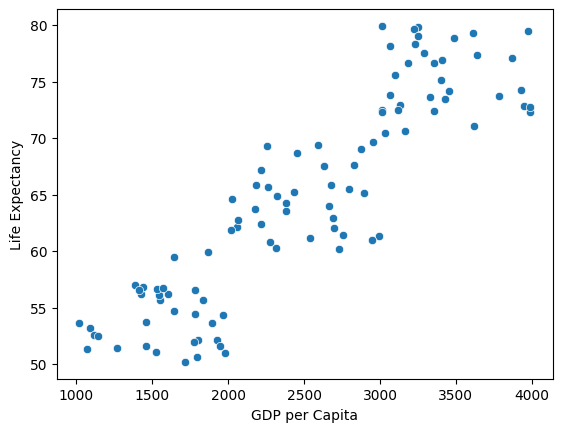

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x=df["GDP per Capita"],y=df["Life Expectancy"])
plt.show()

In [ ]:
features = df.drop('Country', axis=1)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


## 1. n_clusters
What It Is: Number of clusters you want to divide your data into.


Example: If you set n_clusters=3, the algorithm will find 3 clusters in your data.
### 2. init
What It Is: Method for initializing the centroids (starting points) of the clusters.
Options:
'k-means++': A smarter way to pick initial centroids.
'random': Picks random points from the data.


Example: init='k-means++' often gives better results than random initialization.
### 3. n_init
What It Is: Number of times to run the K-means algorithm with different initial centroids.
Purpose: Helps find the best clustering result by trying multiple random starts.


Example: n_init=10 means K-means will run 10 times with different initial centroids and pick the best result.






###  With n_init=2, K-Means will start with 2 different random sets of centroids.

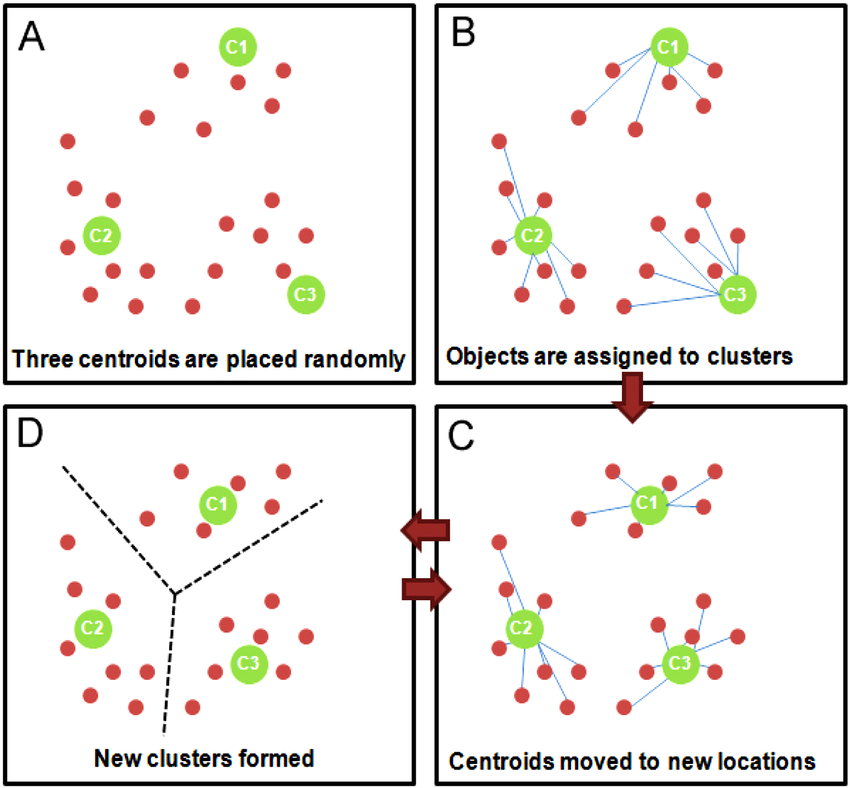

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,init='k-means++',n_init=15,max_iter=300)  # Example with 3 clusters
df['Cluster'] = kmeans.fit_predict(scaled_features)
df

,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate,Country,Cluster
0,1548.814,55.68434,68.20993,15.046950,61.35474,38.558030,Country 1,0
1,1715.189,50.18790,60.97101,21.778170,62.98282,30.117140,Country 2,0
2,1602.763,56.17635,68.37945,17.700080,65.69965,33.599780,Country 3,0
3,1544.883,56.12096,60.96098,22.351940,65.90873,37.299910,Country 4,0
4,1423.655,56.16934,69.76459,24.621890,65.74325,31.716300,Country 5,0
...,...,...,...,...,...,...,...,...
95,3490.305,78.81720,89.06733,9.610557,86.33461,14.979620,Country 96,1
96,3989.410,72.72437,90.52078,5.447473,94.80580,8.621891,Country 97,1
97,3065.304,73.79057,87.71653,7.029712,93.71786,9.706489,Country 98,1
98,3783.234,73.74296,89.55444,5.121566,90.02721,8.782452,Country 99,1


In [ ]:
#Evaluate Clustering

# Silhouette Score: Measure how well the clusters are separated.

from sklearn.metrics import silhouette_score
labels = kmeans.labels_
silhouette_avg = silhouette_score(scaled_features, labels)

print(silhouette_avg) #0.631640138719835

# -1 to 1

0.631640138719835


In [ ]:
df

,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate,Country,Cluster
0,1548.814,55.68434,68.20993,15.046950,61.35474,38.558030,Country 1,0
1,1715.189,50.18790,60.97101,21.778170,62.98282,30.117140,Country 2,0
2,1602.763,56.17635,68.37945,17.700080,65.69965,33.599780,Country 3,0
3,1544.883,56.12096,60.96098,22.351940,65.90873,37.299910,Country 4,0
4,1423.655,56.16934,69.76459,24.621890,65.74325,31.716300,Country 5,0
...,...,...,...,...,...,...,...,...
95,3490.305,78.81720,89.06733,9.610557,86.33461,14.979620,Country 96,1
96,3989.410,72.72437,90.52078,5.447473,94.80580,8.621891,Country 97,1
97,3065.304,73.79057,87.71653,7.029712,93.71786,9.706489,Country 98,1
98,3783.234,73.74296,89.55444,5.121566,90.02721,8.782452,Country 99,1


In [ ]:
cluster_summary = df.groupby("Cluster").agg({
    "GDP per Capita": ["mean"],
    "Life Expectancy": ["mean"],
    "Literacy Rate": ["mean"],
    "Unemployment Rate": ["mean"],
    "Access to Clean Water": ["mean"],
    "Poverty Rate": ["mean"],
    "Country": "count"
})

cluster_summary


,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate,Country
,mean,mean,mean,mean,mean,mean,count
Cluster,,,,,,,
0,1573.592394,54.147095,64.442644,20.614254,65.780478,34.459944,33
1,3403.752559,75.323386,90.383698,7.228377,90.325159,10.329008,34
2,2493.895061,64.452078,78.031502,12.203360,76.961105,25.848923,33


<Axes: xlabel='GDP per Capita', ylabel='Life Expectancy'>

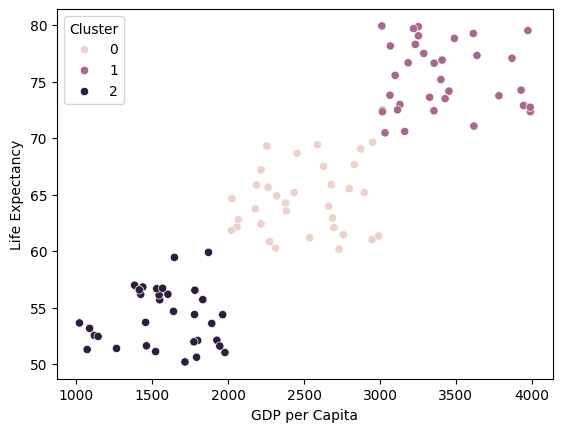

In [ ]:
import seaborn as sns
sns.scatterplot(x="GDP per Capita",y="Life Expectancy",hue="Cluster",data=df)

# 🟢 2️⃣ Hierarchical Clustering

## **Type**
Tree-based clustering  

## **How It Works**
- Starts with each point as its own cluster (**Agglomerative**)  
- Merges clusters step by step  
- Builds a **dendrogram**  
- Cut the tree at desired level to form clusters  

## **Strengths**
- No need to predefine **K**  
- Provides hierarchy insight  
- More interpretable  

## **Weaknesses**
- Slow for large datasets  
- Memory intensive  
- Hard to scale  

## **For Recommendation Systems**
- Small datasets  
- Understanding user similarity structure  
- Best for learning intuition, not large production systems  

---

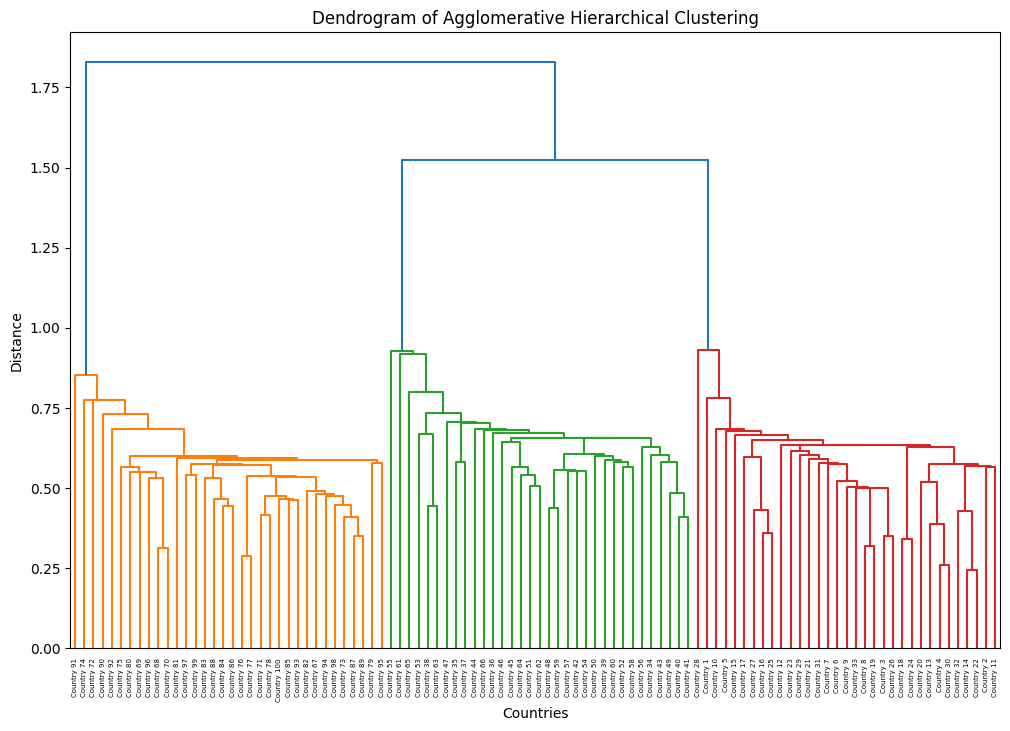

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform hierarchical clustering
Z = linkage(scaled_features, method='single')

# Plot the dendrogram
plt.figure(figsize=(12, 8))
dendrogram(Z, labels=df['Country'].tolist(), leaf_rotation=90)
plt.title('Dendrogram of Agglomerative Hierarchical Clustering')
plt.xlabel('Countries')
plt.ylabel('Distance')
plt.show()


Hierarchical clustering builds a tree of clusters (dendrogram)

There are different ways to measure distance between clusters when merging them → called linkage methods

Common linkages:

single → distance between closest points

complete → distance between farthest points

average → average distance between points in clusters

ward → minimizes total within-cluster variance

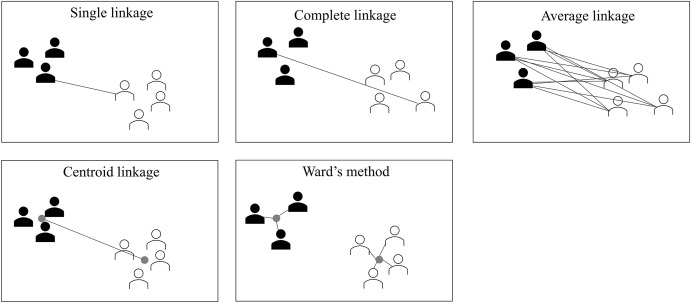

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering #hirearchy
 #bottom up technique
# Example with 3 clusters
hc = AgglomerativeClustering(n_clusters=3,linkage="single")

# Fit and predict clusters
df['Cluster'] = hc.fit_predict(scaled_features)

df.head()

,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate,Country,Cluster
0,1548.814,55.68434,68.20993,15.04695,61.35474,38.55803,Country 1,0
1,1715.189,50.18790,60.97101,21.77817,62.98282,30.11714,Country 2,0
2,1602.763,56.17635,68.37945,17.70008,65.69965,33.59978,Country 3,0
3,1544.883,56.12096,60.96098,22.35194,65.90873,37.29991,Country 4,0
4,1423.655,56.16934,69.76459,24.62189,65.74325,31.71630,Country 5,0


In [ ]:
#Evaluate Clustering

# Silhouette Score: Measure how well the clusters are separated.

from sklearn.metrics import silhouette_score
labels = hc.labels_
silhouette_avg = silhouette_score(scaled_features, labels)

print(silhouette_avg)

0.631640138719835


<Axes: xlabel='GDP per Capita', ylabel='Life Expectancy'>

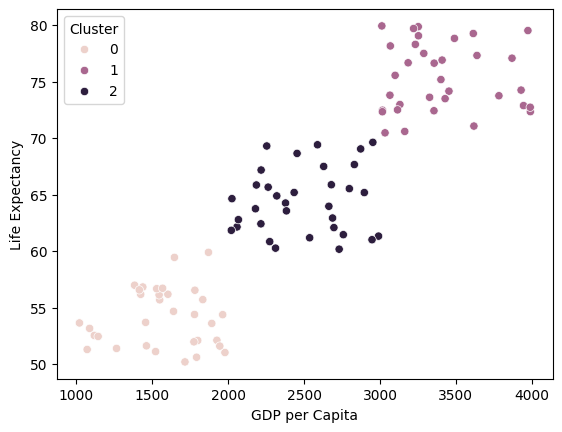

In [ ]:
import seaborn as sns
sns.scatterplot(x="GDP per Capita",y="Life Expectancy",hue="Cluster",data=df)

In [ ]:
cluster_summary = df.groupby("Cluster").agg({
    "GDP per Capita": ["mean"],
    "Life Expectancy": ["mean"],
    "Literacy Rate": ["mean"],
    "Unemployment Rate": ["mean"],
    "Access to Clean Water": ["mean"],
    "Poverty Rate": ["mean"],
    "Country": "count"
})

cluster_summary


,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate,Country
,mean,mean,mean,mean,mean,mean,count
Cluster,,,,,,,
0,1573.592394,54.147095,64.442644,20.614254,65.780478,34.459944,33
1,3403.752559,75.323386,90.383698,7.228377,90.325159,10.329008,34
2,2493.895061,64.452078,78.031502,12.203360,76.961105,25.848923,33



# 🟣 3️⃣ DBSCAN

## **Type**
Density-based clustering  

## **How It Works**
- Forms clusters based on density  
- Points in dense regions form clusters  
- Sparse points are labeled as noise  

## **Strengths**
- Finds irregular-shaped clusters  
- Detects noise automatically  
- No need to define number of clusters  

## **Weaknesses**
- Hard to tune **eps** parameter  
- Struggles with varying densities  
- Not ideal for high-dimensional data  

## **For Recommendation Systems**
- Identify core behavior groups  
- Treat noise users differently  
- Detect abnormal behavior  
- Connects well with anomaly detection systems  

# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## 1. Key Idea
- DBSCAN groups points that are **densely packed together** and marks points in low-density regions as **noise (-1)**.  
- Can find clusters of **arbitrary shape**.  
- No need to specify the number of clusters beforehand (unlike K-Means).  

---

## 2. Important Terms
- **Core Point:** A point with at least `min_samples` points (including itself) within distance `eps`.  
- **Border Point:** A point within `eps` of a core point but with fewer than `min_samples` neighbors.  
- **Noise Point:** A point that is not a core point and not reachable from any core point (`-1` label).  

---

## 3. Parameters
- **`eps` (epsilon):** Radius around a point to consider neighbors.  
  - Smaller → more noise points  
  - Larger → fewer clusters (may merge clusters)  

- **`min_samples`:** Minimum points to form a dense region.  
  - Common default: 4–5  
  - Heuristic: `min_samples ≈ 2 × number of features`  

---

## 4. How DBSCAN Works
1. Pick an unvisited point.  
2. If it has ≥ `min_samples` neighbors within `eps` → **core point**, start a new cluster.  
3. Expand cluster by recursively adding all reachable points.  
4. Repeat until all points are visited.  

---

## 5. Advantages
- Can find clusters of **any shape**.  
- Identifies **outliers/noise**.  
- No need to predefine the number of clusters.  

---

## 6. Disadvantages
- Sensitive to **`eps`**.  
- Struggles with clusters of **varying densities**.  
- Cannot handle very **high-dimensional data** well.  

---

## 7. Choosing Parameters
Use **k-distance graph** to find `eps`:  



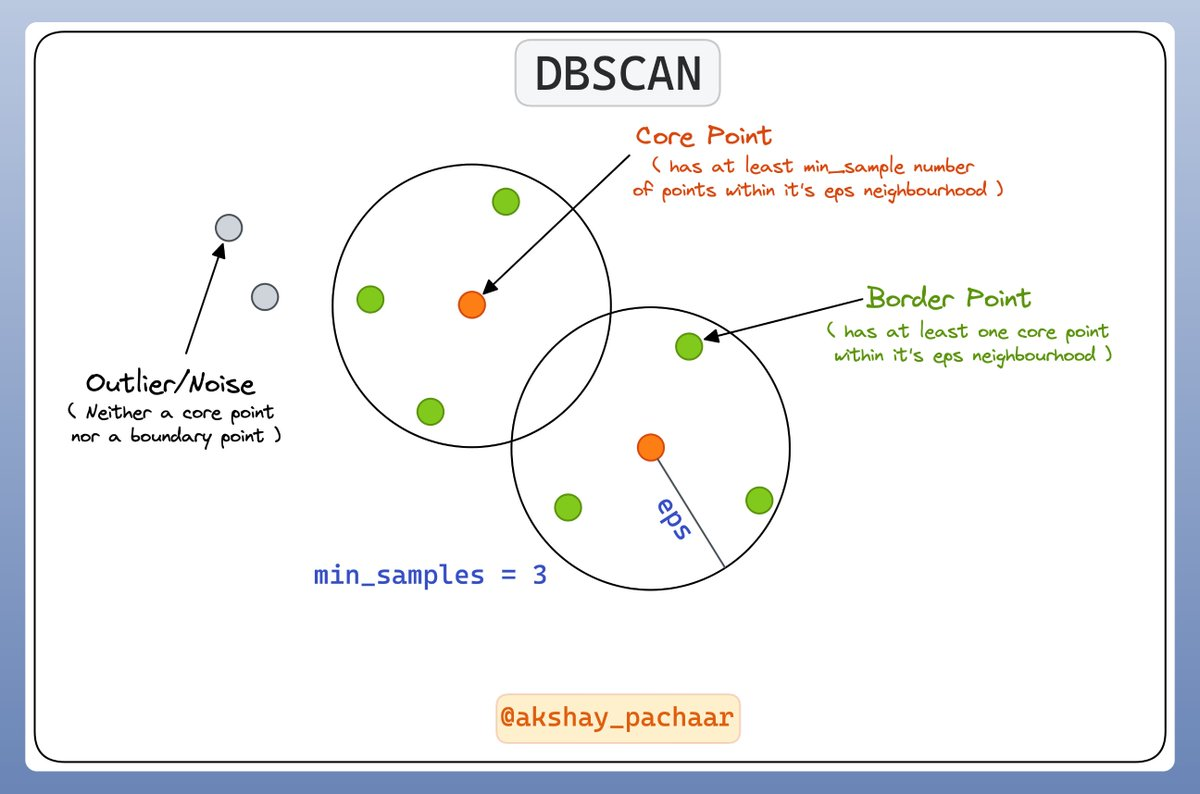

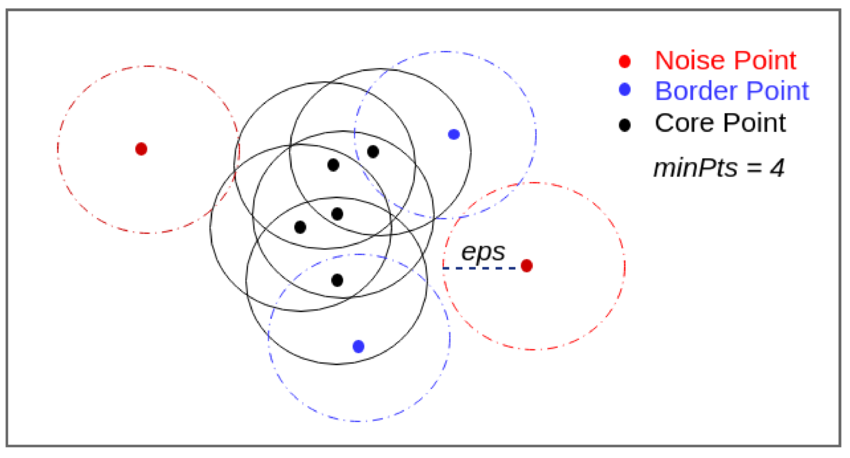

In [ ]:
# DBSCAN
from sklearn.cluster import DBSCAN



db = DBSCAN(eps=.8 ,min_samples=8)  # eps may need tuning, snowball???
labels = db.fit_predict(scaled_features) #pca(pc1, pc2)

# Add labels to DataFrame
df['cluster'] = labels

In [ ]:
#Evaluate Clustering

# Silhouette Score: Measure how well the clusters are separated.

from sklearn.metrics import silhouette_score
labels = db.labels_
silhouette_avg = silhouette_score(scaled_features, labels)

print(silhouette_avg)

0.4318407374283998


In [ ]:
cluster_summary = df.groupby("cluster").agg({
    "GDP per Capita": ["mean"],
    "Life Expectancy": ["mean"],
    "Literacy Rate": ["mean"],
    "Unemployment Rate": ["mean"],
    "Access to Clean Water": ["mean"],
    "Poverty Rate": ["mean"],
    "Country": "count"
})

cluster_summary


,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate,Country
,mean,mean,mean,mean,mean,mean,count
cluster,,,,,,,
-1,2625.719375,65.952918,78.290388,12.616723,77.005882,24.448799,16
0,1566.458871,54.164358,64.183206,20.659889,65.945834,34.632255,31
1,2522.247318,64.015474,78.900363,11.985072,77.066588,25.741491,22
2,3351.403129,75.228569,90.211579,7.185496,90.633798,10.009206,31


<Axes: xlabel='GDP per Capita', ylabel='Poverty Rate'>

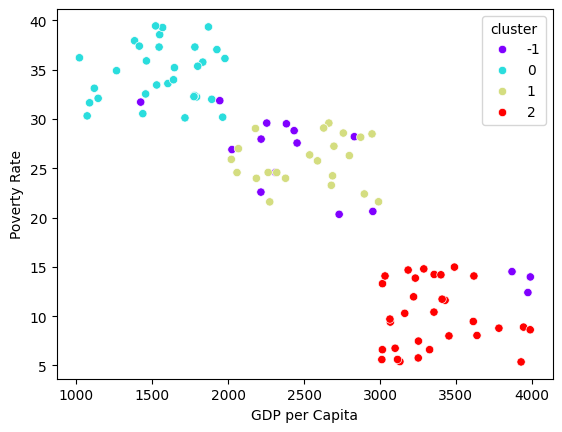

In [ ]:
import seaborn as sns
sns.scatterplot(x="GDP per Capita",y="Poverty Rate",hue="cluster",data=df,palette="rainbow")

| Outlier Detection | Anomaly Detection        |
| ----------------- | ------------------------ |
| Extreme value     | Abnormal pattern         |
| Often univariate  | Multivariate             |
| Global threshold  | Local behavior           |
| Z-score, IQR      | DBSCAN, Isolation Forest |
| Simple            | Context-aware            |



###DBSCAN doesn’t detect “big” points. It detects “lonely” points.

# PROJECT 1


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
feature = "mean radius"

Q1 = df[feature].quantile(0.25)
Q3 = df[feature].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]

print("Number of outliers:", len(outliers))


Number of outliers: 14


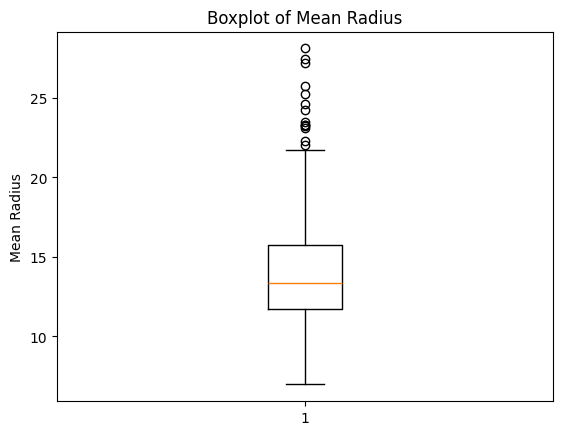

In [ ]:
plt.figure()
plt.boxplot(df[feature])
plt.title("Boxplot of Mean Radius")
plt.ylabel("Mean Radius")
plt.show()


In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outlier_iqr = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)

df["IQR_Outlier"] = outlier_iqr

print("Number of IQR outliers:", outlier_iqr.sum())
df.sample(3)

Number of IQR outliers: 171


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,IQR_Outlier
44,13.17,21.81,85.42,531.5,0.09714,0.10470,0.082590,0.052520,0.1746,0.06177,...,29.89,105.50,740.7,0.1503,0.39040,0.372800,0.16070,0.3693,0.09618,False
276,11.33,14.16,71.79,396.6,0.09379,0.03872,0.001487,0.003333,0.1954,0.05821,...,18.99,77.37,458.0,0.1259,0.07348,0.004955,0.01111,0.2758,0.06386,False
56,19.21,18.57,125.50,1152.0,0.10530,0.12670,0.132300,0.089940,0.1917,0.05961,...,28.14,170.10,2145.0,0.1624,0.35110,0.387900,0.20910,0.3537,0.08294,True


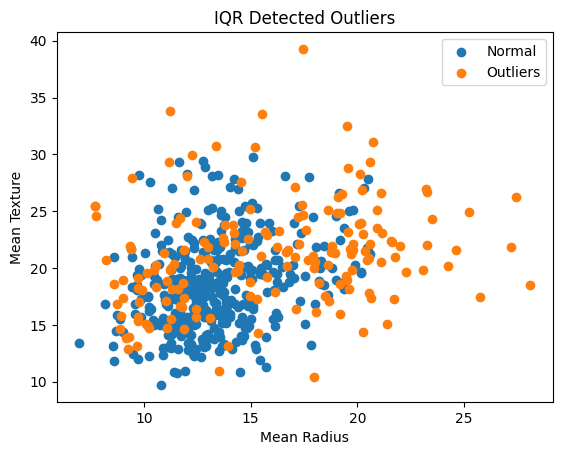

In [ ]:
plt.figure()

normal = df[df["IQR_Outlier"] == False]
outliers = df[df["IQR_Outlier"] == True]

plt.scatter(normal["mean radius"], normal["mean texture"], label="Normal")
plt.scatter(outliers["mean radius"], outliers["mean texture"], label="Outliers")

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("IQR Detected Outliers")

plt.legend()
plt.show()


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

db = DBSCAN(eps=5.5, min_samples=5)
labels = db.fit_predict(X_scaled)

df["DBSCAN_Label"] = labels

print("Number of DBSCAN noise points:", sum(labels == -1))


Number of DBSCAN noise points: 22


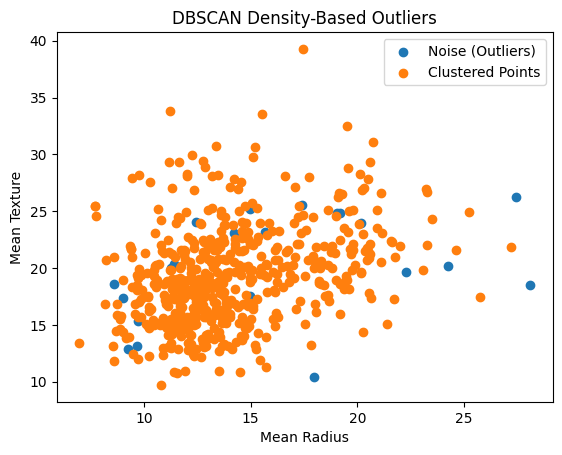

In [ ]:
plt.figure()

# Noise points
noise = df[df["DBSCAN_Label"] == -1]
plt.scatter(noise["mean radius"], noise["mean texture"],
            label="Noise (Outliers)")

# Clustered points
clusters = df[df["DBSCAN_Label"] != -1]
plt.scatter(clusters["mean radius"], clusters["mean texture"],
            label="Clustered Points")

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("DBSCAN Density-Based Outliers")

plt.legend()
plt.show()


In [ ]:
# Get IQR outliers
iqr_outliers = df[df["IQR_Outlier"] == True]

print("Total IQR Outliers:", len(iqr_outliers))
print("\nSample IQR Outliers:\n")

print(iqr_outliers[["mean radius", "mean texture",
                    "mean area", "mean concavity"]].head(10))


Total IQR Outliers: 171

Sample IQR Outliers:

    mean radius  mean texture  mean area  mean concavity
0         17.99         10.38     1001.0          0.3001
1         20.57         17.77     1326.0          0.0869
2         19.69         21.25     1203.0          0.1974
3         11.42         20.38      386.1          0.2414
4         20.29         14.34     1297.0          0.1980
5         12.45         15.70      477.1          0.1578
8         13.00         21.82      519.8          0.1859
9         12.46         24.04      475.9          0.2273
12        19.17         24.80     1123.0          0.2065
14        13.73         22.61      578.3          0.2128


In [ ]:
# Get DBSCAN noise (-1)
dbscan_outliers = df[df["DBSCAN_Label"] == -1]

print("Total DBSCAN Outliers:", len(dbscan_outliers))
print("\nSample DBSCAN Outliers:\n")

print(dbscan_outliers[["mean radius", "mean texture",
                       "mean area", "mean concavity"]].head(10))


Total DBSCAN Outliers: 22

Sample DBSCAN Outliers:

     mean radius  mean texture  mean area  mean concavity
0         17.990         10.38     1001.0         0.30010
3         11.420         20.38      386.1         0.24140
9         12.460         24.04      475.9         0.22730
12        19.170         24.80     1123.0         0.20650
38        14.990         25.20      698.8         0.02398
42        19.070         24.81     1104.0         0.21070
68         9.029         17.33      250.5         0.31300
78        20.180         23.97     1245.0         0.37540
108       22.270         19.67     1509.0         0.42640
122       24.250         20.20     1761.0         0.42680


1️⃣ Project Title

# **Bank Customer Segmentation and Anomaly Detection using DBSCAN & K-Means**

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Normal customer data (95 customers)
normal_data = {
    "CustomerID": range(1, 96),
    "Age": np.random.randint(20, 65, 95),
    "AccountBalance": np.random.randint(1000, 10000, 95),
    "NumTransactions": np.random.randint(5, 50, 95),
    "MonthlySpending": np.random.randint(200, 2000, 95)
}

normal_df = pd.DataFrame(normal_data)

# Inject anomalies (5 customers)
anomaly_data = {
    "CustomerID": range(96, 101),
    "Age": [30, 50, 40, 60, 25],
    "AccountBalance": [50000, 70000, 80000, 100000, 60000],  # unusually high balances
    "NumTransactions": [200, 180, 220, 250, 190],             # unusually high transactions
    "MonthlySpending": [15000, 18000, 20000, 25000, 16000]    # unusually high spending
}

anomaly_df = pd.DataFrame(anomaly_data)

# Combine normal + anomalies
bank_df = pd.concat([normal_df, anomaly_df], ignore_index=True)

bank_df


,CustomerID,Age,AccountBalance,NumTransactions,MonthlySpending
0,1,58,3027,15,762
1,2,48,3695,21,637
2,3,34,6258,42,1999
3,4,62,6618,28,1506
4,5,27,7736,9,226
...,...,...,...,...,...
95,96,30,50000,200,15000
96,97,50,70000,180,18000
97,98,40,80000,220,20000
98,99,60,100000,250,25000


In [ ]:

bank_df.describe()

,CustomerID,Age,AccountBalance,NumTransactions,MonthlySpending
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,50.500000,41.660000,9034.640000,35.490000,1950.76000
std,29.011492,13.304681,15210.701488,41.941878,3995.64068
min,1.000000,20.000000,1206.000000,5.000000,216.00000
25%,25.750000,30.000000,3775.250000,16.000000,694.25000
50%,50.500000,41.500000,6253.500000,27.500000,1123.50000
75%,75.250000,53.250000,7962.250000,39.000000,1519.75000
max,100.000000,64.000000,100000.000000,250.000000,25000.00000


In [ ]:
# Select features
X = bank_df[["AccountBalance", "MonthlySpending","NumTransactions","Age"]].values
X

array([[  3027,    762,     15,     58],
       [  3695,    637,     21,     48],
       [  6258,   1999,     42,     34],
       [  6618,   1506,     28,     62],
       [  7736,    226,      9,     27],
       [  1391,    425,     38,     40],
       [  6892,   1500,     10,     58],
       [  4561,    997,     26,     38],
       [  7184,   1832,     15,     42],
       [  4099,    483,     20,     30],
       [  7278,   1078,     37,     30],
       [  9392,   1159,     13,     43],
       [  4104,   1704,     10,     55],
       [  8215,    652,     20,     59],
       [  3454,   1219,     33,     43],
       [  9996,   1015,      7,     22],
       [  3731,    858,     24,     41],
       [  9154,   1739,     40,     21],
       [  6056,    746,     23,     43],
       [  9110,   1415,     30,     63],
       [  4840,   1272,      7,     49],
       [  2028,   1735,     23,     57],
       [  8385,    216,     24,     21],
       [  1502,   1395,     36,     40],
       [  7910, 

In [ ]:
# DBSCAN for anomaly detection
db = DBSCAN(eps=10000, min_samples=5)
db.fit(X)

# Labels: -1 = anomaly, 0,1,... = cluster IDs
bank_df['DBSCAN_Label'] = db.labels_
bank_df


,CustomerID,Age,AccountBalance,NumTransactions,MonthlySpending,DBSCAN_Label
0,1,58,3027,15,762,0
1,2,48,3695,21,637,0
2,3,34,6258,42,1999,0
3,4,62,6618,28,1506,0
4,5,27,7736,9,226,0
...,...,...,...,...,...,...
95,96,30,50000,200,15000,-1
96,97,50,70000,180,18000,-1
97,98,40,80000,220,20000,-1
98,99,60,100000,250,25000,-1


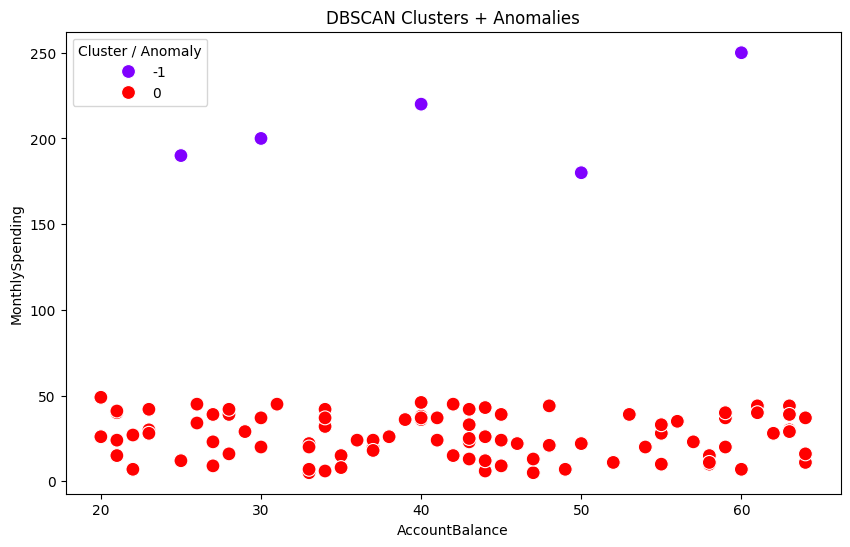

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Scatter plot with cluster labels as hue
sns.scatterplot(
    data=bank_df,
    x='Age',
    y='NumTransactions',
    hue='DBSCAN_Label',        # color points by cluster
    palette='rainbow',           # nice color palette
    # anomalies get different marker
    s=100                      # size of points
)

plt.title('DBSCAN Clusters + Anomalies')
plt.xlabel('AccountBalance')
plt.ylabel('MonthlySpending')
plt.legend(title='Cluster / Anomaly')
plt.show()


In [ ]:
from sklearn.cluster import KMeans

# Step 1: Remove anomalies
good_data = bank_df[bank_df['DBSCAN_Label'] != -1]

# Step 2: Features for K-Means
X_good = good_data[['AccountBalance', 'MonthlySpending','NumTransactions',"Age"]].values

# Step 3: Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
good_data['KMeans_Cluster'] = kmeans.fit_predict(X_good)

good_data


/tmp/ipython-input-2407401534.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_data['KMeans_Cluster'] = kmeans.fit_predict(X_good)


,CustomerID,Age,AccountBalance,NumTransactions,MonthlySpending,DBSCAN_Label,KMeans_Cluster
0,1,58,3027,15,762,0,2
1,2,48,3695,21,637,0,0
2,3,34,6258,42,1999,0,0
3,4,62,6618,28,1506,0,1
4,5,27,7736,9,226,0,1
...,...,...,...,...,...,...,...
90,91,44,2707,26,1171,0,2
91,92,26,6791,34,670,0,1
92,93,28,6535,42,1366,0,1
93,94,43,5931,42,1315,0,0


In [ ]:
cluster_summary = good_data.groupby("KMeans_Cluster").agg({
    "AccountBalance": ["mean"],
    "NumTransactions": ["mean"],
    "MonthlySpending": ["mean"],
    "Age": ["mean"],

})

cluster_summary


,AccountBalance,NumTransactions,MonthlySpending,Age
,mean,mean,mean,mean
KMeans_Cluster,,,,
0,4984.931034,26.000000,1123.620690,40.758621
1,7915.636364,25.818182,1021.431818,39.568182
2,2300.590909,28.136364,1070.363636,47.181818


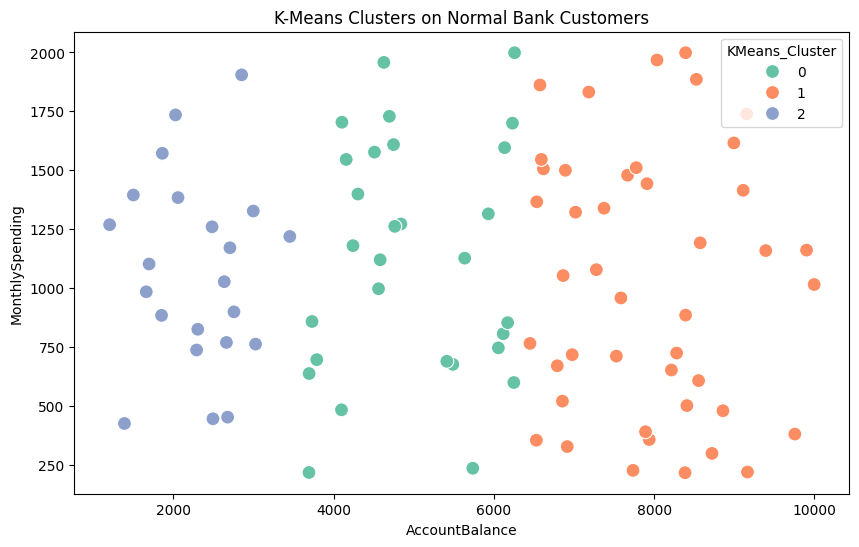

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=good_data,
    x='AccountBalance',
    y='MonthlySpending',
    hue='KMeans_Cluster',
    palette='Set2',
    s=100
)
plt.title('K-Means Clusters on Normal Bank Customers')
plt.show()


# project2

# **Content-Based Book Recommendation System with K-Means Clustering**

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Sample book dataset
books = pd.DataFrame({
    "BookID":[101,102,103,104],
    "Genre":["Programming","AI","Data Sci","Fiction"],
    "Author":["John Smith","Alice Johnson","Bob Lee","Emily White"],
    "Type":["eBook","Hardcover","eBook","Paperback"],
    "Tags":["coding, beginner","ai, machine learning","data, statistics","fantasy, adventure"]
})

books





,BookID,Genre,Author,Type,Tags
0,101,Programming,John Smith,eBook,"coding, beginner"
1,102,AI,Alice Johnson,Hardcover,"ai, machine learning"
2,103,Data Sci,Bob Lee,eBook,"data, statistics"
3,104,Fiction,Emily White,Paperback,"fantasy, adventure"


In [ ]:
enc = OneHotEncoder()
cat_features = books[["Genre","Author","Type"]]
encoded = enc.fit_transform(cat_features).toarray()
encoded

array([[0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1.],
       [1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0.]])

In [ ]:
tags = books["Tags"].str.get_dummies(sep=", ")
tags


,adventure,ai,beginner,coding,data,fantasy,machine learning,statistics
0,0,0,1,1,0,0,0,0
1,0,1,0,0,0,0,1,0
2,0,0,0,0,1,0,0,1
3,1,0,0,0,0,1,0,0


In [ ]:
X = np.hstack([encoded, tags.values])
X


array([[0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0.,
        0., 0., 0.],
       [1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0.,
        0., 1., 0.],
       [0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.,
        0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0.,
        1., 0., 0.]])

In [ ]:
# NOT NEED BYW
#One-hot categories
encoded_feature_names = enc.get_feature_names_out(["Genre","Author","Type"])

# Tag feature names
tag_feature_names = tags.columns.tolist()

# Combine all feature names
all_feature_names = list(encoded_feature_names) + tag_feature_names
X_df = pd.DataFrame(X, columns=all_feature_names)
X_df


,Genre_AI,Genre_Data Sci,Genre_Fiction,Genre_Programming,Author_Alice Johnson,Author_Bob Lee,Author_Emily White,Author_John Smith,Type_Hardcover,Type_Paperback,Type_eBook,adventure,ai,beginner,coding,data,fantasy,machine learning,statistics
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
# Apply K-Means clustering
k = 2  # choose number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
books["Cluster"] = kmeans.fit_predict(X)

print(books)

   BookID        Genre         Author       Type                  Tags  \
0     101  Programming     John Smith      eBook      coding, beginner   
1     102           AI  Alice Johnson  Hardcover  ai, machine learning   
2     103     Data Sci        Bob Lee      eBook      data, statistics   
3     104      Fiction    Emily White  Paperback    fantasy, adventure   

   Cluster  
0        0  
1        0  
2        0  
3        1  


In [ ]:
def recommend_similar_books(book_id, books):
    cluster = books[books["BookID"] == book_id]["Cluster"].values[0]
    similar_books = books[(books["Cluster"] == cluster) & (books["BookID"] != book_id)]
    return similar_books["BookID"].tolist()

recs = recommend_similar_books(104, books)
print("Books similar to 104:", recs)


Books similar to 104: []
